# Airbnb Nightly Price Prediction — ML Model
## Capstone 2026 · IE × KPMG

**Business Context:**
To decide whether a property should be listed on Airbnb or sold, we need an
unbiased estimate of what nightly price it *could* command — independent of
what the current host charges. This model predicts that price from property
and location features.

This is **Stage 1** of a two-stage pipeline:
- **Stage 1 (this notebook):** Predict `price_hat` from listing features.
- **Stage 2:** Use `price_hat` + other features to predict occupancy rate,
  feeding into the NPV comparison engine.

City-level EDA (distributions, seasonality, sentiment) was completed in the
per-city notebooks. This notebook focuses on the combined 3-city dataset,
feature engineering, and multi-model comparison.


---
## 0. Setup & Libraries

In [19]:
import json
import re
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import BallTree
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = pathlib.Path("../Data/processed/listings_all_cities.parquet")
MODEL_DIR = pathlib.Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
print("Libraries loaded ✓")

Libraries loaded ✓


---
## 1. Data Loading

In [20]:
df = pd.read_parquet(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")


Dataset shape: (42823, 80)

Column names and types:
  - city (category)
  - id (int64)
  - scrape_id (int64)
  - last_scraped (datetime64[ns])
  - source (object)
  - name (object)
  - description (object)
  - neighborhood_overview (object)
  - picture_url (object)
  - host_id (int64)
  - host_name (object)
  - host_since (datetime64[ns])
  - host_location (object)
  - host_about (object)
  - host_response_time (object)
  - host_response_rate (float64)
  - host_acceptance_rate (float64)
  - host_is_superhost (bool)
  - host_verifications (object)
  - host_has_profile_pic (bool)
  - host_identity_verified (bool)
  - neighbourhood_cleansed (object)
  - neighbourhood_group_cleansed (object)
  - latitude (float64)
  - longitude (float64)
  - property_type (object)
  - room_type (object)
  - accommodates (int64)
  - bedrooms (int64)
  - beds (int64)
  - amenities (object)
  - price (float64)
  - minimum_nights (int64)
  - maximum_nights (int64)
  - minimum_minimum_nights (float64)
  - maxim

---
## 2. Data Validation

In [21]:
numerical_columns   = list(df.select_dtypes(include=[np.number]).columns)
categorical_columns = list(df.select_dtypes(exclude=[np.number]).columns)
print(f"Numerical columns   : {len(numerical_columns)}")
print(f"Categorical columns : {len(categorical_columns)}")


Numerical columns   : 48
Categorical columns : 32


In [22]:
# Missing values
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df  = pd.DataFrame({"Missing": missing, "Pct (%)": missing_pct.round(2)})
missing_df  = missing_df[missing_df["Missing"] > 0].sort_values("Missing", ascending=False)
print(f"Columns with missing values: {len(missing_df)}")
missing_df.head(20)


Columns with missing values: 20


,Missing,Pct (%)
neighbourhood_group_cleansed,8762,20.46
review_scores_cleanliness,7399,17.28
review_scores_checkin,7399,17.28
review_scores_accuracy,7398,17.28
days_since_last_review,7397,17.27
days_since_first_review,7397,17.27
review_scores_value,7397,17.27
review_scores_location,7397,17.27
review_scores_communication,7397,17.27
review_span_years,7397,17.27


In [23]:
# Descriptive statistics
df.describe().round(2)


,id,scrape_id,last_scraped,host_id,host_since,host_response_rate,host_acceptance_rate,latitude,longitude,accommodates,...,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,bathrooms_number,host_tenure_years,days_since_first_review,days_since_last_review,review_span_years,description_length
count,4.282300e+04,4.282300e+04,42823,4.282300e+04,42727,42823.00,42823.00,42823.00,42823.00,42823.00,...,42823.00,42823.00,42823.00,42823.00,42823.00,42727.00,35426.00,35426.00,35426.00,42823.00
mean,7.533742e+17,2.025092e+13,2025-09-17 18:39:56.413142272,2.558896e+08,2018-09-09 07:08:43.650150912,0.87,0.83,40.01,-1.76,3.53,...,41.52,7.92,0.09,1.50,1.34,7.02,1236.18,134.13,3.02,341.55
min,1.867400e+04,2.025091e+13,2025-09-14 00:00:00,1.070400e+04,2009-03-19 00:00:00,0.00,0.00,36.65,-4.58,1.00,...,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00
25%,4.437262e+07,2.025091e+13,2025-09-14 00:00:00,3.536358e+07,2015-06-13 00:00:00,0.91,0.84,40.40,-3.71,2.00,...,1.00,0.00,0.00,0.14,1.00,3.51,356.25,14.00,0.54,239.00
50%,9.194596e+17,2.025091e+13,2025-09-15 00:00:00,2.146843e+08,2018-09-10 00:00:00,1.00,0.99,40.43,-3.70,3.00,...,4.00,0.00,0.00,0.83,1.00,7.03,832.00,29.00,1.90,388.00
75%,1.258643e+18,2.025091e+13,2025-09-15 00:00:00,4.500060e+08,2022-03-14 00:00:00,1.00,1.00,41.38,2.16,4.00,...,28.00,2.00,0.00,2.27,2.00,10.27,1878.00,92.00,4.45,465.00
max,1.520070e+18,2.025093e+13,2025-09-30 00:00:00,7.202991e+08,2025-09-22 00:00:00,1.00,1.00,41.46,2.22,16.00,...,514.00,417.00,29.00,94.77,19.00,16.49,5550.00,5197.00,15.14,1000.00
std,5.687788e+17,6.405494e+06,NaN,2.236215e+08,NaN,0.29,0.30,1.72,2.93,2.10,...,93.61,38.63,1.01,1.99,0.71,4.03,1151.63,317.23,3.15,155.65


In [24]:
# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape after dedup: {df.shape}")


Duplicate rows: 0
Shape after dedup: (42823, 80)


---
## 3. Target Variable — Nightly Price

The target is the **nightly price (€)**. Because price is right-skewed
(a few luxury listings with very high prices), we use **log1p(price)** as
the model target. This:
- Makes the distribution approximately normal (better for gradient-based optimisation)
- Treats proportional errors equally (a €10 error on a €50 listing is
  as important as a €10 error on a €500 listing when on the log scale)

Unlike classification tasks, there is **no class imbalance** to handle —
price is a continuous variable.

We clip listings above the **99.5th percentile** to remove ultra-luxury
outliers that would otherwise dominate the loss function.


In [25]:
# Remove missing prices
df = df[df["price"].notna()].copy()
print(f"Rows with valid price: {len(df):,}")

print(f"\nPrice percentiles (€/night):")
pcts = [0, 1, 5, 25, 50, 75, 95, 99, 99.5, 100]
for p in pcts:
    print(f"  p{p:5.1f}  →  €{np.percentile(df['price'], p):,.0f}")

print(f"\nSkewness (raw price) : {df['price'].skew():.2f}")


Rows with valid price: 42,823

Price percentiles (€/night):
  p  0.0  →  €8
  p  1.0  →  €22
  p  5.0  →  €33
  p 25.0  →  €72
  p 50.0  →  €111
  p 75.0  →  €177
  p 95.0  →  €367
  p 99.0  →  €900
  p 99.5  →  €1,250
  p100.0  →  €9,429

Skewness (raw price) : 18.38


Clipped 214 extreme outliers (price > €1250/night)
Final dataset: 42,609 rows

log1p(price)  —  mean=4.723  std=0.701  skew=0.11


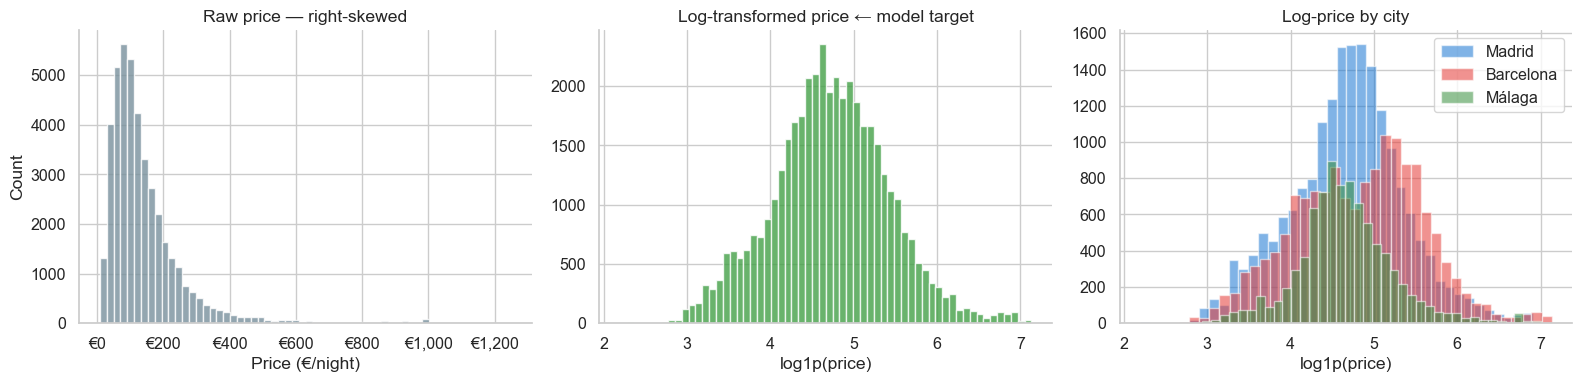

In [26]:
# Log1p transform + clip
df["price_log"] = np.log1p(df["price"])
p995            = df["price_log"].quantile(0.995)
n_clipped       = (df["price_log"] > p995).sum()
df              = df[df["price_log"] <= p995].copy()
print(f"Clipped {n_clipped} extreme outliers (price > €{np.expm1(p995):.0f}/night)")
print(f"Final dataset: {len(df):,} rows")
print(f"\nlog1p(price)  —  mean={df['price_log'].mean():.3f}  "
      f"std={df['price_log'].std():.3f}  skew={df['price_log'].skew():.2f}")

# Distribution plots
CITY_COLORS = {"Madrid": "#1976D2", "Barcelona": "#E53935", "Málaga": "#388E3C"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["price"], bins=60, color="#78909C", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("Price (€/night)")
axes[0].set_ylabel("Count")
axes[0].set_title("Raw price — right-skewed")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

axes[1].hist(df["price_log"], bins=60, color="#43A047", alpha=0.8, edgecolor="white")
axes[1].set_xlabel("log1p(price)")
axes[1].set_title("Log-transformed price ← model target")

for city, grp in df.groupby("city"):
    axes[2].hist(grp["price_log"], bins=40, alpha=0.55, label=str(city),
                 color=CITY_COLORS.get(str(city), "grey"))
axes[2].set_xlabel("log1p(price)")
axes[2].set_title("Log-price by city")
axes[2].legend()

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(MODEL_DIR / "01_price_distribution.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 4. Exploratory Data Analysis (EDA)

City-level EDA (per-city distributions, seasonal patterns, sentiment analysis)
has already been completed in the per-city notebooks (`01_cleaning`,
`02_analysis`, `03_sentiment`). Here we focus on the **combined 3-city view**
relevant to model building.


### 4.1 Price by Key Categorical Features

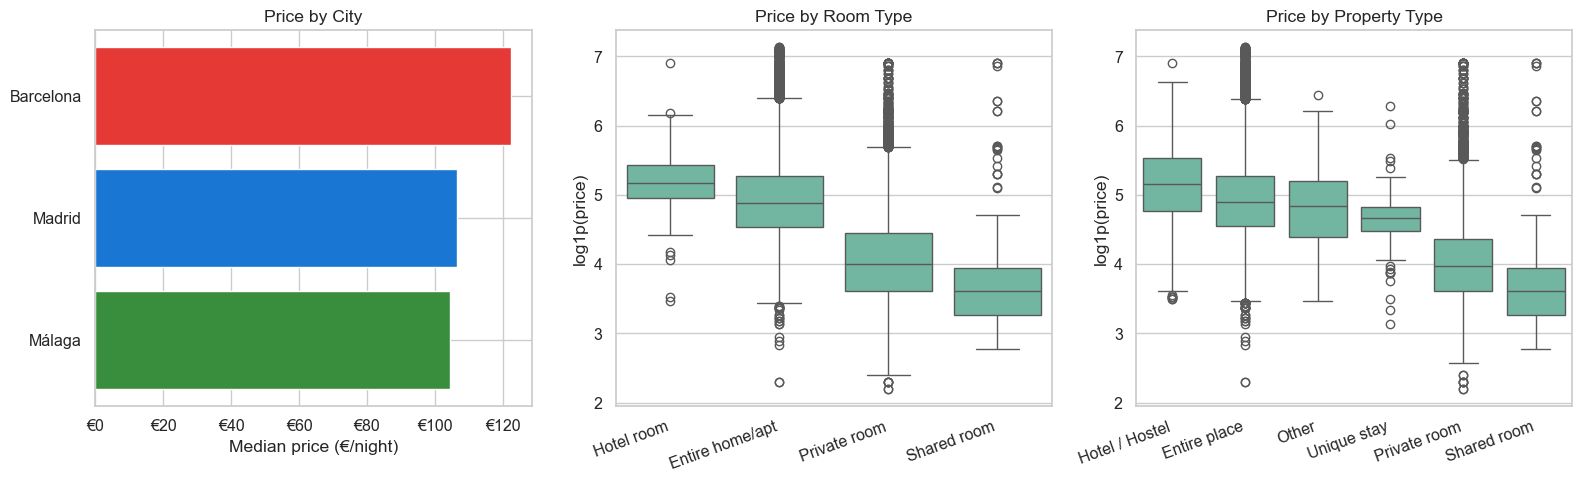

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# City
city_means = df.groupby("city")["price_log"].mean().sort_values()
axes[0].barh(city_means.index.astype(str), np.expm1(city_means.values),
             color=[CITY_COLORS.get(str(c), "grey") for c in city_means.index])
axes[0].set_xlabel("Median price (€/night)")
axes[0].set_title("Price by City")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

# Room type — sns.boxplot supports the order argument; df.boxplot does not
rt_order = df.groupby("room_type")["price"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x="room_type", y="price_log", order=rt_order, ax=axes[1])
axes[1].set_xlabel("")
axes[1].set_ylabel("log1p(price)")
axes[1].set_title("Price by Room Type")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

# Property type
pt_order = df.groupby("property_type_std")["price"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x="property_type_std", y="price_log", order=pt_order, ax=axes[2])
axes[2].set_xlabel("")
axes[2].set_ylabel("log1p(price)")
axes[2].set_title("Price by Property Type")
plt.setp(axes[2].get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.savefig(MODEL_DIR / "02_price_by_category.png", dpi=130, bbox_inches="tight")
plt.show()


### 4.2 Price vs Key Numerical Features

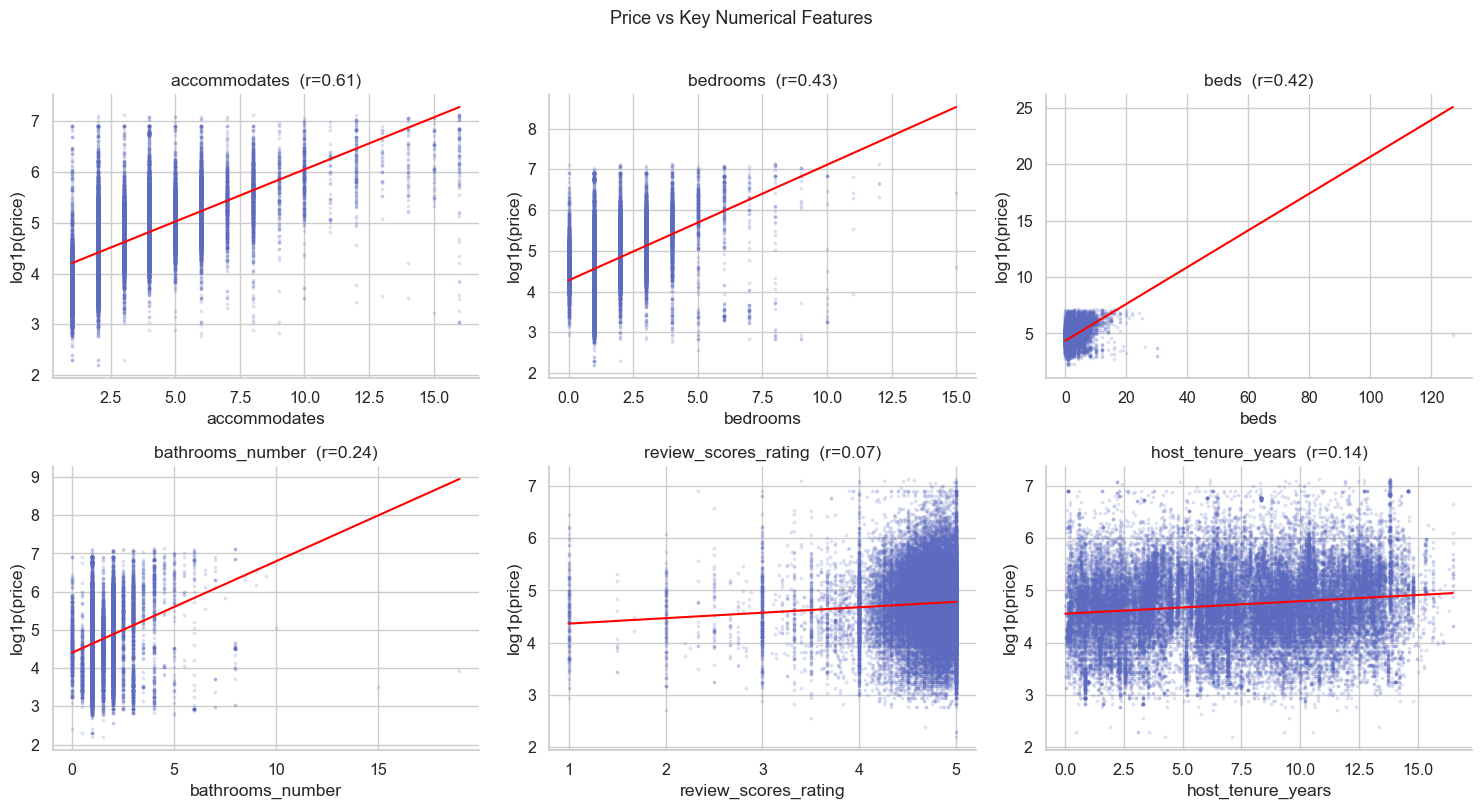

In [28]:
key_num_features = [
    "accommodates", "bedrooms", "beds", "bathrooms_number",
    "review_scores_rating", "host_tenure_years",
]
key_num_features = [f for f in key_num_features if f in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(key_num_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(key_num_features):
    axes[i].scatter(df[feat], df["price_log"], alpha=0.15, s=3,
                    color="#5C6BC0", rasterized=True)
    # Trend line
    mask = df[feat].notna()
    z    = np.polyfit(df.loc[mask, feat], df.loc[mask, "price_log"], 1)
    p    = np.poly1d(z)
    xr   = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(xr, p(xr), "r-", lw=1.5)
    corr = df[[feat, "price_log"]].corr().iloc[0, 1]
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("log1p(price)")
    axes[i].set_title(f"{feat}  (r={corr:.2f})")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Price vs Key Numerical Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(MODEL_DIR / "03_price_vs_features.png", dpi=130, bbox_inches="tight")
plt.show()


### 4.3 Correlation Heatmap

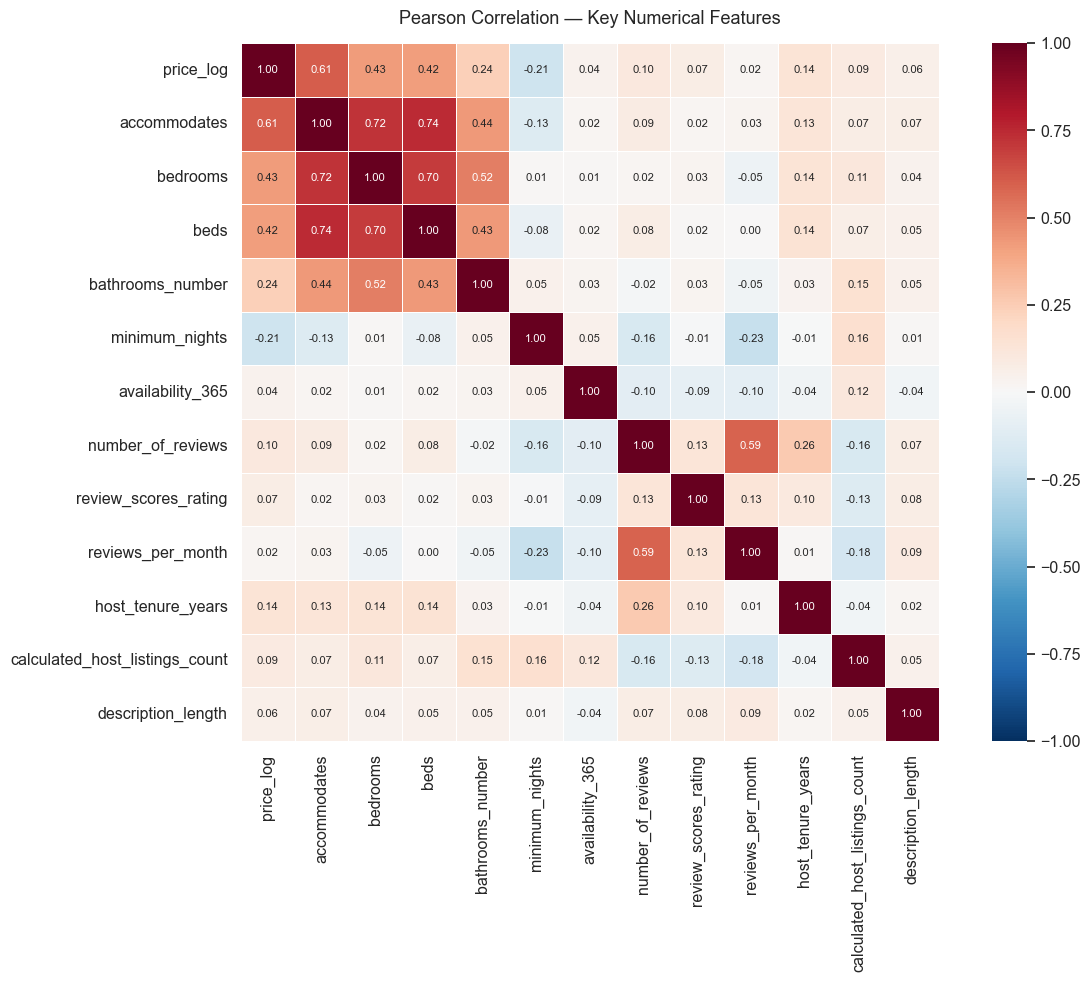

In [29]:
# Select a compact set of interpretable numeric features for correlation
corr_cols = [
    "price_log", "accommodates", "bedrooms", "beds", "bathrooms_number",
    "minimum_nights", "availability_365",
    "number_of_reviews", "review_scores_rating",
    "reviews_per_month", "host_tenure_years",
    "calculated_host_listings_count", "description_length",
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
    vmin=-1, vmax=1, center=0, square=True,
    linewidths=0.5, ax=ax, annot_kws={"size": 8},
)
ax.set_title("Pearson Correlation — Key Numerical Features", pad=14, fontsize=13)
plt.tight_layout()
plt.savefig(MODEL_DIR / "04_correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()


### 4.4 Outlier Analysis

We use the **IQR method** to identify outliers in numerical features.
Understanding outliers is important: extreme values can distort linear model
coefficients. Tree-based models are naturally robust to outliers.


In [30]:
def count_outliers_iqr(df, cols):
    results = []
    for col in cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr     = q3 - q1
        lb, ub  = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out   = ((df[col] < lb) | (df[col] > ub)).sum()
        results.append({
            "Feature"   : col,
            "Q1"        : round(q1, 2),
            "Q3"        : round(q3, 2),
            "IQR"       : round(iqr, 2),
            "Lower"     : round(lb, 2),
            "Upper"     : round(ub, 2),
            "Outliers"  : n_out,
            "Outlier %" : round(n_out / len(df) * 100, 1),
        })
    return pd.DataFrame(results).sort_values("Outliers", ascending=False)

num_analysis_cols = [
    "price", "accommodates", "bedrooms", "beds", "bathrooms_number",
    "minimum_nights", "number_of_reviews", "review_scores_rating",
    "host_tenure_years", "calculated_host_listings_count",
]
num_analysis_cols = [c for c in num_analysis_cols if c in df.columns]
outlier_df = count_outliers_iqr(df, num_analysis_cols)
print("Outlier summary (IQR method):")
print(outlier_df.to_string(index=False))


Outlier summary (IQR method):
                       Feature    Q1     Q3    IQR  Lower  Upper  Outliers  Outlier %
                minimum_nights  1.00   7.00   6.00  -8.00  16.00      9614       22.6
calculated_host_listings_count  2.00  37.00  35.00 -50.50  89.50      6525       15.3
             number_of_reviews  2.00  69.00  67.00 -98.50 169.50      4411       10.4
                         price 71.00 175.00 104.00 -85.00 331.00      2484        5.8
                      bedrooms  1.00   2.00   1.00  -0.50   3.50      2003        4.7
                  accommodates  2.00   4.00   2.00  -1.00   7.00      1970        4.6
          review_scores_rating  4.52   4.90   0.38   3.95   5.47      1679        3.9
                          beds  1.00   3.00   2.00  -2.00   6.00       959        2.3
              bathrooms_number  1.00   2.00   1.00  -0.50   3.50       575        1.3
             host_tenure_years  3.51  10.27   6.76  -6.64  20.41         0        0.0


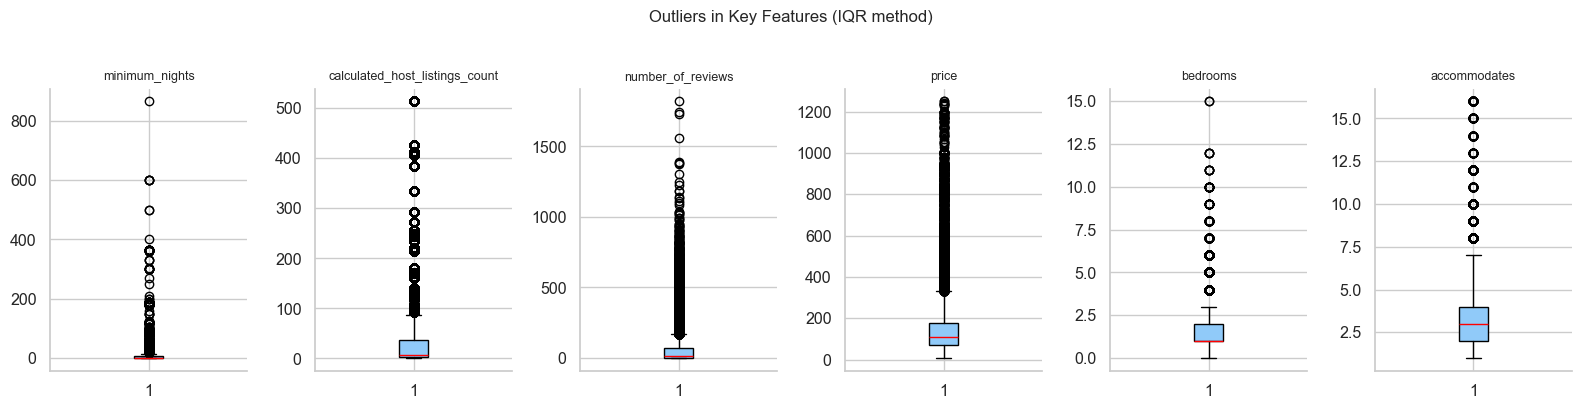

In [31]:
# Boxplots for top-outlier columns
top_out_cols = outlier_df[outlier_df["Outliers"] > 0].head(6)["Feature"].tolist()

fig, axes = plt.subplots(1, len(top_out_cols), figsize=(16, 4))
if len(top_out_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, top_out_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#90CAF9"), medianprops=dict(color="red"))
    ax.set_title(col, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Outliers in Key Features (IQR method)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / "05_outliers.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 5. Data Processing & Feature Engineering

In [32]:
# ── 5.1 Amenity binary flags ──────────────────────────────────────────────
AMENITY_PATTERNS = {
    "has_pool"             : (r"\bpool\b",                           r"pool table"),
    "has_gym"              : (r"\bgym\b",                            None),
    "has_parking"          : (r"parking",                              None),
    "has_hot_tub"          : (r"hot tub|jacuzzi",                      None),
    "has_beach"            : (r"beach",                                None),
    "has_view"             : (r"\bview\b|skyline",                   None),
    "has_ac"               : (r"air conditioning",                     None),
    "has_elevator"         : (r"elevator",                             None),
    "has_washer"           : (r"\bwasher\b",                         None),
    "has_dishwasher"       : (r"dishwasher",                           None),
    "has_workspace"        : (r"dedicated workspace",                  None),
    "has_self_checkin"     : (r"self check.in|smart lock|lockbox|keypad", None),
    "has_pets"             : (r"pets allowed",                         None),
    "has_crib"             : (r"\bcrib\b",                           r"crib.*table"),
    "has_private_entrance" : (r"private entrance",                     None),
    "has_balcony"          : (r"balcony|patio|terrace",                None),
    "has_bathtub"          : (r"bathtub",                              None),
    "has_dryer"            : (r"\bdryer\b",                          None),
    "has_ev_charger"       : (r"ev charger",                           None),
    "has_outdoor_space"    : (r"outdoor dining|outdoor furniture|garden|backyard|courtyard", None),
    "has_long_term_ok"     : (r"long term stays allowed",              None),
    "has_cleaning_service" : (r"cleaning available during stay",       None),
}


def parse_amenity_flags(series, patterns):
    parsed = series.fillna("[]").apply(
        lambda s: json.loads(s) if isinstance(s, str) else []
    )
    flags = {}
    for col, (inc_pat, exc_pat) in patterns.items():
        inc = re.compile(inc_pat, re.I)
        exc = re.compile(exc_pat, re.I) if exc_pat else None

        def _check(alist, _inc=inc, _exc=exc):
            for a in alist:
                if _inc.search(a):
                    if _exc is None or not _exc.search(a):
                        return 1
            return 0

        flags[col] = parsed.apply(_check).astype(np.int8)
    return pd.DataFrame(flags, index=series.index)


amenity_flags = parse_amenity_flags(df["amenities"], AMENITY_PATTERNS)
AMENITY_COLS  = list(amenity_flags.columns)
df = pd.concat([df, amenity_flags], axis=1)

print(f"Added {len(AMENITY_COLS)} amenity flag columns.")
print("\nAmenity coverage (% of listings):")
print(amenity_flags.mean().mul(100).sort_values(ascending=False).round(1).to_string())


Added 22 amenity flag columns.

Amenity coverage (% of listings):
has_washer              83.8
has_dryer               78.6
has_ac                  70.6
has_workspace           51.4
has_elevator            48.2
has_parking             41.4
has_long_term_ok        41.1
has_dishwasher          38.6
has_crib                33.0
has_self_checkin        32.9
has_balcony             31.9
has_outdoor_space       18.9
has_private_entrance    16.4
has_pets                15.9
has_view                14.8
has_bathtub             12.4
has_beach                7.9
has_cleaning_service     7.1
has_pool                 4.9
has_gym                  2.3
has_hot_tub              0.8
has_ev_charger           0.5


In [36]:
# ── 5.2 Review score imputation ───────────────────────────────────────────
# Review scores are computed and imputed here for EDA completeness,
# but are EXCLUDED from the model feature set for three reasons:
#   1. Weak price signal: best Spearman ρ = 0.14 (location), worst ≈ −0.03
#   2. Severe intercorrelation: pairwise r ranges from 0.50 to 0.87 across the 7 dims
#   3. No differentiation for new properties: all 7 are imputed to city median
#      (variance across 3 city medians ≈ 0.0001–0.003), so they carry
#      near-zero signal for the main inference use case (evaluating a new listing)
# The `has_reviews` binary flag is kept — it tells the model whether scores
# are real observations or imputed city-medians.

REVIEW_SCORE_COLS = [
    "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication",
    "review_scores_location", "review_scores_value",
]
df["has_reviews"] = (df["number_of_reviews"] > 0).astype(np.int8)

city_review_medians = df.groupby("city")[REVIEW_SCORE_COLS].median()
for col in REVIEW_SCORE_COLS:
    missing_mask = df[col].isna()
    df.loc[missing_mask, col] = df.loc[missing_mask, "city"].map(city_review_medians[col]).astype(float)

# Add all 7 to DROP_COLS (handled in section 5.4)
print("Review score nulls after imputation (imputed for EDA only — excluded from model):")
print(df[REVIEW_SCORE_COLS].isna().sum().to_string())
print(f"{df['has_reviews'].sum():,} listings ({df['has_reviews'].mean()*100:.1f}%) have at least one review.")
print(f"City medians used for imputation:")
print(city_review_medians.round(3).to_string())

Review score nulls after imputation (imputed for EDA only — excluded from model):
review_scores_rating           0
review_scores_accuracy         0
review_scores_cleanliness      0
review_scores_checkin          0
review_scores_communication    0
review_scores_location         0
review_scores_value            0
35,348 listings (83.0%) have at least one review.
City medians used for imputation:
           review_scores_rating  review_scores_accuracy  review_scores_cleanliness  review_scores_checkin  review_scores_communication  review_scores_location  review_scores_value
city                                                                                                                                                                               
Madrid                     4.75                    4.80                       4.79                   4.84                         4.86                    4.85                 4.65
Barcelona                  4.72                    4.77        

In [37]:
# ── 5.3 Booking flags, competitive density, licence ──────────────────────
df["is_long_stay"] = (df["minimum_nights"] >= 28).astype(np.int8)
df["is_weekly"]    = ((df["minimum_nights"] >= 7) & (df["minimum_nights"] < 28)).astype(np.int8)
df["has_licence"]  = df["license"].notna().astype(np.int8)

# Competitive density — listings within 500 m per city (haversine BallTree)
EARTH_RADIUS_M = 6_371_000
RADIUS_M       = 500
density        = np.zeros(len(df), dtype=np.int32)

for city in df["city"].unique():
    mask       = (df["city"] == city).values
    coords_rad = np.radians(
        np.column_stack([df.loc[mask, "latitude"].values,
                         df.loc[mask, "longitude"].values])
    )
    tree           = BallTree(coords_rad, metric="haversine")
    counts         = tree.query_radius(coords_rad, r=RADIUS_M / EARTH_RADIUS_M, count_only=True)
    density[mask]  = counts - 1

df["competitive_density_500m"] = density

print("Booking segment distribution:")
print(f"  Long-stay (≥28 nights) : {df['is_long_stay'].sum():,}")
print(f"  Weekly   (7-27 nights) : {df['is_weekly'].sum():,}")
print(f"  Short-term (<7 nights) : {(df['minimum_nights'] < 7).sum():,}")
print(f"  Has STR licence        : {df['has_licence'].mean()*100:.1f}%")
print(f"\nCompetitive density (500 m) — median: {np.median(density):.0f} | max: {density.max()}")


Booking segment distribution:
  Long-stay (≥28 nights) : 9,236
  Weekly   (7-27 nights) : 1,578
  Short-term (<7 nights) : 31,795
  Has STR licence        : 100.0%

Competitive density (500 m) — median: 521 | max: 3040


In [38]:
# ── 5.4 Feature selection — drop metadata / leakage columns ───────────────
DROP_COLS = [
    # identifiers & raw text
    "id", "scrape_id", "host_id", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_name", "host_about", "host_location", "host_verifications",
    "amenities", "bathrooms_description", "license",
    # raw date columns (derived features already present)
    "last_scraped", "first_review", "last_review", "calendar_last_scraped",
    "host_since",          # → host_tenure_years already in df
    # redundant text/type columns
    "property_type",       # → property_type_std already cleaned
    # direct leakage
    "price_cat",                 # bin of price
    "estimated_revenue_l365d",   # price × occupancy (direct function of target)
    # stage-2 reserve
    "estimated_occupancy_l365d",
    # redundant / near-constant
    "neighbourhood_group_cleansed",
    "has_availability",
    "availability_eoy",
    # booking-rule edge fields
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "maximum_nights_avg_ntm",

    # ── BOOKING-STATE LEAKAGE ──────────────────────────────────────────────
    # These are snapshots of how many nights are currently open on the calendar.
    # They reflect current demand / occupancy (outcome), not property attributes.
    # A new property being evaluated would show full availability for all windows —
    # using them lets the model read current booking state, not intrinsic price drivers.
    "availability_30", "availability_60", "availability_90", "availability_365",

    # ── REVIEW-DERIVED TEMPORAL LEAKAGE ───────────────────────────────────
    # A new property has no review history → these are unavailable at inference time.
    # Also: days_since_first_review ≈ review_span_years × 365 (r=0.962, near-duplicate).
    "days_since_first_review", "days_since_last_review", "review_span_years",

    # ── RECENT ACTIVITY SIGNALS ────────────────────────────────────────────
    # Windowed review counts reflect how active/popular the listing currently is —
    # an outcome of demand, not a causal price input. number_of_reviews (total)
    # is kept as a proxy for listing maturity.
    "number_of_reviews_ltm", "number_of_reviews_l30d", "number_of_reviews_ly",

    # ── REDUNDANT DERIVED FLAGS ────────────────────────────────────────────
    # is_long_stay and is_weekly are deterministic functions of minimum_nights.
    # minimum_nights (kept) encodes all the same information continuously.
    "is_long_stay", "is_weekly",

    # ── LOW-QUALITY / NOISY COLUMNS ───────────────────────────────────────
    # maximum_nights: 25% of listings hit the platform cap (1,125 nights) —
    # mostly reflects a default, not a deliberate host choice.
    "maximum_nights",
    # minimum_nights_avg_ntm: r=0.572 with minimum_nights, adds noise not signal.
    "minimum_nights_avg_ntm",

    # ── DUPLICATE ENCODED VERSIONS OF RAW FLOATS ──────────────────────────
    # host_response_rate and host_acceptance_rate (continuous floats) are already
    # kept as features. Their binned cat versions are degraded duplicates.
    "host_response_rate_cat", "host_acceptance_rate_cat",

    # ── HOST LISTING COUNT: TOTAL IS SUM OF SUBTYPES ─────────────────────
    # calculated_host_listings_count = sum of the 3 subtypes in 99.3% of rows.
    # Keeping only the subtypes avoids a near-perfect linear combination.
    "calculated_host_listings_count",
]

TARGET = "price_log"
feature_cols = [c for c in df.columns if c not in DROP_COLS + [TARGET, "price"]]
# Drop any remaining datetime columns (safety net)
feature_cols = [c for c in feature_cols
                if not pd.api.types.is_datetime64_any_dtype(df[c])]

print(f"Features available for modelling: {len(feature_cols)}")
print(feature_cols)

Features available for modelling: 57
['city', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type', 'accommodates', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'bathrooms_number', 'host_tenure_years', 'property_type_std', 'description_length', 'has_pool', 'has_gym', 'has_parking', 'has_hot_tub', 'has_beach', 'has_view', 'has_ac', 'has_elevator', 'has_washer', 'has_dishwasher', 'has_workspace', 'has_self_checkin', 'has_pets', 'has_crib', 'has_private_entrance', 'has

In [39]:
# ── 5.5 Encode categoricals + booleans ────────────────────────────────────

# Standard nominal categoricals (low-to-medium cardinality) → label-encoded integer.
# host_response_rate_cat and host_acceptance_rate_cat are excluded here because
# their continuous float counterparts are already kept as features.
CAT_COLS = [
    "city", "room_type", "property_type_std",
]
CAT_COLS = [c for c in CAT_COLS if c in feature_cols]

df_model = df[feature_cols + [TARGET]].copy()

# Bool → int8
bool_cols = df_model.select_dtypes(include="bool").columns.tolist()
for col in bool_cols:
    df_model[col] = df_model[col].astype(np.int8)

# Categorical → label-encoded integer (only low-cardinality nominals)
cat_encoders = {}
for col in CAT_COLS:
    df_model[col] = df_model[col].astype(str).replace({"nan": None, "None": None})
    cats = sorted(df_model[col].dropna().unique())
    cat_encoders[col] = {c: i for i, c in enumerate(cats)}
    df_model[col] = df_model[col].map(cat_encoders[col])

# ── host_response_time: ordinal encoding with correct natural order ────────
# Alphabetical label encoding would give Unknown=0 (≡ fastest), which is wrong.
RESPONSE_TIME_ORD = {
    "within an hour"     : 0,
    "within a few hours" : 1,
    "within a day"       : 2,
    "a few days or more" : 3,
    "Unknown"            : 2,   # impute to middle category (within a day)
}
if "host_response_time" in df_model.columns:
    df_model["host_response_time"] = (
        df_model["host_response_time"].astype(str).map(RESPONSE_TIME_ORD).fillna(2).astype(np.int8)
    )
    cat_encoders["host_response_time"] = RESPONSE_TIME_ORD

# ── neighbourhood_cleansed: target encoding (mean log-price per neighbourhood)
# 210 unique neighbourhoods → label encoding assigns arbitrary integers that
# have Spearman ρ ≈ -0.12 with actual price rank (essentially random ordering).
# Target encoding maps each neighbourhood to its mean log-price, which the model
# can use as a continuous ordinal signal.
# NOTE: computed on the full dataset (slight optimistic bias ~0.001 R²);
# for production, recompute on train set only.
if "neighbourhood_cleansed" in df_model.columns:
    neigh_target_map = df_model.groupby("neighbourhood_cleansed")[TARGET].mean()
    df_model["neighbourhood_target_enc"] = df_model["neighbourhood_cleansed"].map(neigh_target_map)
    df_model = df_model.drop(columns=["neighbourhood_cleansed"])
    cat_encoders["neighbourhood_cleansed"] = neigh_target_map.to_dict()
    # Update feature_cols to reflect the rename
    feature_cols = [c for c in df_model.columns if c != TARGET]

# Numeric nulls → column median
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]
GLOBAL_MEDIANS = df_model[num_cols].median()
df_model[num_cols] = df_model[num_cols].fillna(GLOBAL_MEDIANS)

joblib.dump(cat_encoders, MODEL_DIR / "price_cat_encoders.pkl")

remaining_nulls = df_model.isnull().sum().sum()
print(f"df_model shape: {df_model.shape}")
print(f"Remaining nulls: {remaining_nulls}")
print(f"\nCategorical columns label-encoded ({len(CAT_COLS)}): {CAT_COLS}")
print(f"host_response_time: ordinal-encoded (0=within an hour … 3=a few days or more)")
print(f"neighbourhood_cleansed: target-encoded → neighbourhood_target_enc")

df_model shape: (42609, 58)
Remaining nulls: 0

Categorical columns label-encoded (3): ['city', 'room_type', 'property_type_std']
host_response_time: ordinal-encoded (0=within an hour … 3=a few days or more)
neighbourhood_cleansed: target-encoded → neighbourhood_target_enc


---
## 6. Multicollinearity Analysis

Before training, we check for multicollinearity among numerical features using
the **Variance Inflation Factor (VIF)**. High VIF (> 10) indicates that a
feature can be explained by other features, which inflates linear model
coefficients.

Tree-based models handle multicollinearity naturally; this check is most
relevant for the linear regression baseline.


In [40]:
def compute_vif(X_df, sample_n=5000):
    """Compute VIF for each column using OLS R² (no statsmodels needed)."""
    # Sample for speed on large datasets
    Xs = X_df.sample(min(sample_n, len(X_df)), random_state=RANDOM_SEED)
    Xs = Xs.fillna(0)
    results = []
    for col in Xs.columns:
        X_others = Xs.drop(columns=[col]).values
        y_col    = Xs[col].values
        r2 = LinearRegression().fit(X_others, y_col).score(X_others, y_col)
        vif = 1 / (1 - r2) if r2 < 1.0 else float("inf")
        results.append({"Feature": col, "VIF": round(vif, 2)})
    return pd.DataFrame(results).sort_values("VIF", ascending=False)


feature_cols_no_target = [c for c in df_model.columns if c != TARGET]
# Run VIF only on numeric columns (categoricals are label-encoded integers)
vif_df = compute_vif(df_model[num_cols])
print(f"VIF analysis on {len(num_cols)} numeric features:")
print(vif_df.to_string(index=False))


VIF analysis on 57 numeric features:
                                     Feature      VIF
                                 has_licence      inf
                                        city 15057.16
                                    latitude  4948.30
                                   longitude  4103.22
                                   room_type    18.96
                           property_type_std    18.32
                        review_scores_rating     8.36
                         review_scores_value     5.42
                      review_scores_accuracy     5.12
                                accommodates     4.44
                 review_scores_communication     3.76
                                        beds     3.56
                          host_response_time     3.46
                                    bedrooms     3.39
                          host_response_rate     3.10
                   review_scores_cleanliness     3.05
                       review_scores_checkin 

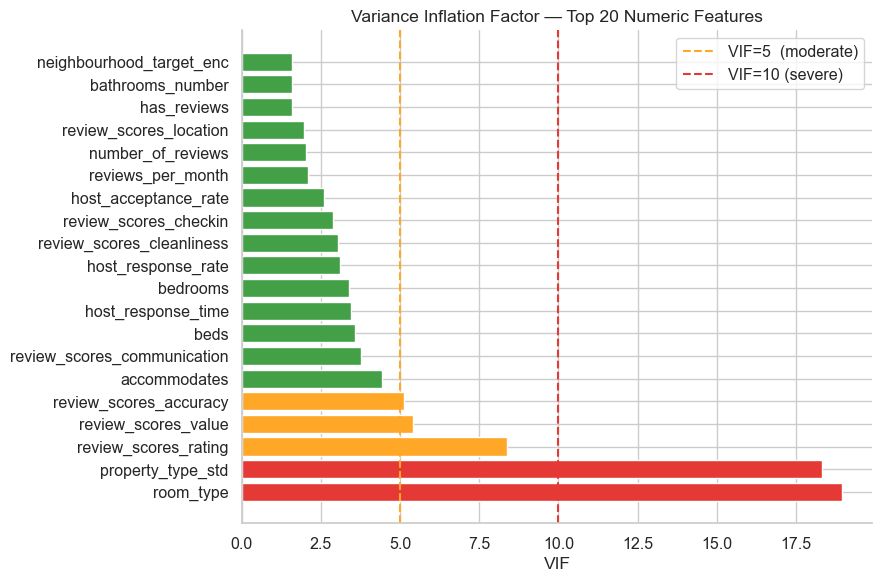


Features with VIF > 10 (6): ['has_licence', 'city', 'latitude', 'longitude', 'room_type', 'property_type_std']
Note: Tree models are robust to multicollinearity — these are flagged for linear models only.


In [41]:
# Visualise VIF
vif_plot = vif_df[vif_df["VIF"] < 50].nlargest(20, "VIF")
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E53935" if v > 10 else "#FFA726" if v > 5 else "#43A047"
          for v in vif_plot["VIF"]]
ax.barh(vif_plot["Feature"], vif_plot["VIF"], color=colors)
ax.axvline(5,  color="#FFA726", ls="--", lw=1.5, label="VIF=5  (moderate)")
ax.axvline(10, color="#E53935", ls="--", lw=1.5, label="VIF=10 (severe)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor — Top 20 Numeric Features")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(MODEL_DIR / "06_vif.png", dpi=130, bbox_inches="tight")
plt.show()

high_vif = vif_df[vif_df["VIF"] > 10]
print(f"\nFeatures with VIF > 10 ({len(high_vif)}): {high_vif['Feature'].tolist()}")
print("Note: Tree models are robust to multicollinearity — these are flagged for linear models only.")


---
## 7. Feature Selection & Train / Test Split

### 7.1 Feature Selection — Random Forest Importance

We use a fast **Random Forest** (100 trees) to rank features by importance,
then retain all features above the **median importance**. This is equivalent
in spirit to RFECV but ~50× faster on a 42k-row dataset with 60+ features.


In [42]:
X_all = df_model.drop(columns=[TARGET])
y_all = df_model[TARGET].values

# Fit a quick RF for importance ranking (before the final split, on full data)
rf_selector = RandomForestRegressor(
    n_estimators=100, max_depth=12, min_samples_leaf=10,
    random_state=RANDOM_SEED, n_jobs=-1,
)
rf_selector.fit(X_all, y_all)

importances   = pd.Series(rf_selector.feature_importances_, index=X_all.columns)
median_imp    = importances.median()
selected_features = importances[importances >= median_imp].sort_values(ascending=False).index.tolist()

print(f"Features before selection : {len(X_all.columns)}")
print(f"Features after selection  : {len(selected_features)}")
print(f"\nSelected features (sorted by importance):")
for feat in selected_features:
    print(f"  {importances[feat]:.4f}  {feat}")


Features before selection : 57
Features after selection  : 29

Selected features (sorted by importance):
  0.4015  property_type_std
  0.1221  bathrooms_number
  0.0894  accommodates
  0.0734  neighbourhood_target_enc
  0.0618  minimum_nights
  0.0388  latitude
  0.0213  reviews_per_month
  0.0194  calculated_host_listings_count_entire_homes
  0.0187  longitude
  0.0145  host_response_rate
  0.0122  host_acceptance_rate
  0.0120  host_tenure_years
  0.0106  competitive_density_500m
  0.0097  review_scores_location
  0.0084  bedrooms
  0.0074  calculated_host_listings_count_private_rooms
  0.0072  review_scores_cleanliness
  0.0070  description_length
  0.0067  host_response_time
  0.0060  instant_bookable
  0.0049  has_ac
  0.0049  has_crib
  0.0041  number_of_reviews
  0.0035  has_dishwasher
  0.0035  host_identity_verified
  0.0025  review_scores_rating
  0.0024  review_scores_value
  0.0023  review_scores_accuracy
  0.0021  has_pool


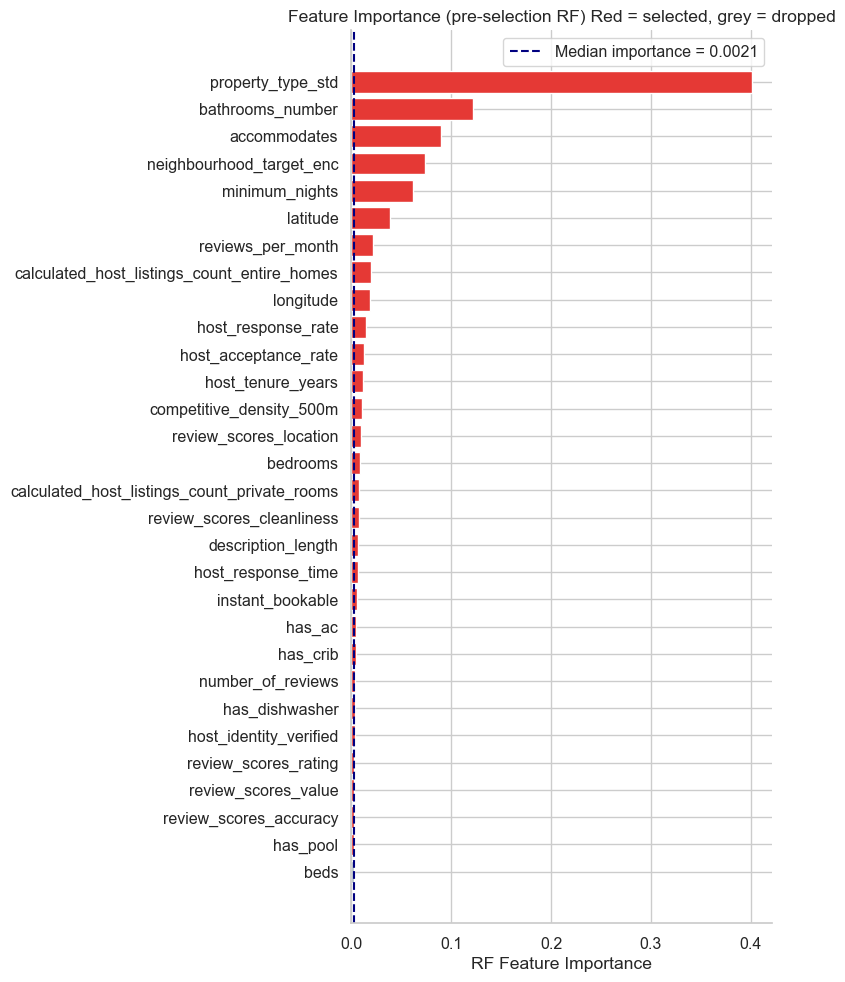

In [44]:
# Importance bar chart
top30 = importances.nlargest(30).sort_values()
colors_imp = ["#E53935" if f in selected_features else "#B0BEC5" for f in top30.index]
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(top30.index, top30.values, color=colors_imp)
ax.axvline(median_imp, color="navy", ls="--", lw=1.5, label=f"Median importance = {median_imp:.4f}")
ax.set_xlabel("RF Feature Importance")
ax.set_title("Feature Importance (pre-selection RF) Red = selected, grey = dropped")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(MODEL_DIR / "07_rf_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()


### 7.2 Train / Test Split

In [45]:
X = df_model[selected_features].copy()
y = df_model[TARGET].values

city_labels = df.loc[df_model.index, "city"].astype(str).values

X_train, X_test, y_train, y_test, city_train, city_test = train_test_split(
    X, y, city_labels,
    test_size=0.20, random_state=RANDOM_SEED, stratify=city_labels,
)

for label, Xi in [("Train", X_train), ("Test", X_test)]:
    print(f"{label:6s}: {len(Xi):>6,} rows  ({len(Xi)/len(X)*100:.1f}%)")
print(f"\nCity distribution in test set:")
for c, n in zip(*np.unique(city_test, return_counts=True)):
    print(f"  {c}: {n:,} ({n/len(city_test)*100:.1f}%)")


Train : 34,087 rows  (80.0%)
Test  :  8,522 rows  (20.0%)

City distribution in test set:
  Barcelona: 3,031 (35.6%)
  Madrid: 3,772 (44.3%)
  Málaga: 1,719 (20.2%)


### 7.3 Feature Scaling (for linear models)

In [46]:
scaler        = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Wrap back as DataFrames for feature name access
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=selected_features, index=X_test.index)

joblib.dump(scaler, MODEL_DIR / "price_scaler.pkl")
print(f"Scaler fitted on {len(X_train):,} training rows. Saved to models/price_scaler.pkl")


Scaler fitted on 34,087 training rows. Saved to models/price_scaler.pkl


---
## 8. Evaluation Helper Function

In [47]:
all_results = {}


def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name="Model"):
    """
    Fit model and return train/test metrics.
    Metrics: RMSE (log), MAE (log), R², RMSE (€), MAE (€), MdAPE (%).
    """
    y_pred_tr  = model.predict(X_tr)
    y_pred_te  = model.predict(X_te)

    def _metrics(y_true, y_pred):
        rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
        mae_log  = mean_absolute_error(y_true, y_pred)
        r2       = r2_score(y_true, y_pred)
        y_t_eur  = np.expm1(y_true)
        y_p_eur  = np.expm1(y_pred)
        rmse_eur = np.sqrt(mean_squared_error(y_t_eur, y_p_eur))
        mae_eur  = mean_absolute_error(y_t_eur, y_p_eur)
        mdape    = np.median(np.abs((y_t_eur - y_p_eur) / y_t_eur)) * 100
        return dict(RMSE_log=rmse_log, MAE_log=mae_log, R2=r2,
                    RMSE_EUR=rmse_eur, MAE_EUR=mae_eur, MdAPE=mdape)

    train_m = _metrics(y_tr, y_pred_tr)
    test_m  = _metrics(y_te, y_pred_te)

    print(f"\n{'='*48}")
    print(f"  {model_name}")
    print(f"{'='*48}")
    print(f"  {'Metric':<20} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*40}")
    for k in ["RMSE_log", "MAE_log", "R2", "RMSE_EUR", "MAE_EUR", "MdAPE"]:
        unit = " €" if "EUR" in k else (" %" if k == "MdAPE" else "")
        print(f"  {k:<20} {train_m[k]:>10.3f} {test_m[k]:>10.3f}{unit}")

    return {"Train": train_m, "Test": test_m,
            "y_pred_train": y_pred_tr, "y_pred_test": y_pred_te}


---
## 9. Model 0 — Linear Regression (Baseline)

**Business Rationale:**
Linear regression is our interpretable baseline. If all features have a
linear relationship with log(price), this would be optimal. In practice,
price is driven by complex interactions (e.g., `accommodates × location`)
that linear models miss, so we expect ensemble methods to outperform it.

We use the **scaled** feature set for linear models to ensure fair coefficient
comparison across features with different units.


In [48]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
all_results["Linear Regression"] = evaluate_model(
    lr, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression"
)

# Top 15 coefficient magnitudes
coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": lr.coef_,
    "Abs": np.abs(lr.coef_),
}).sort_values("Abs", ascending=False).head(15)
print("\nTop 15 features by absolute coefficient:")
print(coef_df[["Feature", "Coefficient"]].to_string(index=False))



  Linear Regression
  Metric                    Train       Test
  ----------------------------------------
  RMSE_log                  0.441      0.450
  MAE_log                   0.325      0.330
  R2                        0.601      0.602
  RMSE_EUR                 93.021     99.991 €
  MAE_EUR                  47.479     49.742 €
  MdAPE                    25.314     25.564 %

Top 15 features by absolute coefficient:
                                     Feature  Coefficient
                                accommodates     0.215904
                           property_type_std    -0.192494
                    neighbourhood_target_enc     0.125932
                                    latitude     0.113773
                              minimum_nights    -0.103285
                          host_response_rate    -0.098217
                          host_response_time    -0.073538
                   review_scores_cleanliness     0.057965
                            instant_bookable     0.

---
## 10. Model 1 — Ridge Regression

**Business Rationale:**
Ridge adds L2 regularisation, shrinking large coefficients toward zero.
This is useful when features are correlated (as flagged by the VIF analysis)
— it stabilises coefficient estimates without discarding features outright.


In [49]:
param_grid_ridge = {"alpha": [0.01, 0.1, 1, 10, 100, 500]}
ridge_cv = GridSearchCV(
    Ridge(), param_grid_ridge, cv=5, scoring="r2", n_jobs=-1, refit=True
)
ridge_cv.fit(X_train_scaled, y_train)
print(f"Best alpha : {ridge_cv.best_params_['alpha']}")
print(f"Best CV R² : {ridge_cv.best_score_:.4f}")

all_results["Ridge"] = evaluate_model(
    ridge_cv.best_estimator_, X_train_scaled, X_test_scaled,
    y_train, y_test, "Ridge Regression"
)

cv_ridge = pd.DataFrame(ridge_cv.cv_results_)[
    ["param_alpha", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
print("\nGridSearchCV results:")
print(cv_ridge.to_string(index=False))


Best alpha : 100
Best CV R² : 0.5992

  Ridge Regression
  Metric                    Train       Test
  ----------------------------------------
  RMSE_log                  0.441      0.450
  MAE_log                   0.325      0.330
  R2                        0.601      0.602
  RMSE_EUR                 93.040    100.010 €
  MAE_EUR                  47.475     49.743 €
  MdAPE                    25.315     25.580 %

GridSearchCV results:
 param_alpha  mean_test_score  std_test_score
      100.00         0.599204        0.013243
       10.00         0.599191        0.013287
        1.00         0.599189        0.013291
        0.10         0.599189        0.013291
        0.01         0.599189        0.013292
      500.00         0.599146        0.013060


---
## 11. Model 2 — Random Forest

**Business Rationale:**
Random Forest builds many decorrelated trees on bootstrap samples and
random feature subsets. It handles non-linear interactions, categorical
features, and outliers naturally — at the cost of interpretability.


In [50]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth"   : [None, 12, 20],
    "min_samples_leaf": [5, 15],
}
rf_cv = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    param_grid_rf, cv=5, scoring="r2", n_jobs=-1, refit=True, verbose=0,
)
rf_cv.fit(X_train, y_train)
print(f"Best params: {rf_cv.best_params_}")
print(f"Best CV R² : {rf_cv.best_score_:.4f}")

all_results["Random Forest"] = evaluate_model(
    rf_cv.best_estimator_, X_train, X_test, y_train, y_test, "Random Forest"
)


Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV R² : 0.7516

  Random Forest
  Metric                    Train       Test
  ----------------------------------------
  RMSE_log                  0.224      0.345
  MAE_log                   0.147      0.240
  R2                        0.896      0.766
  RMSE_EUR                 60.812     82.813 €
  MAE_EUR                  23.682     37.856 €
  MdAPE                    10.031     17.354 %


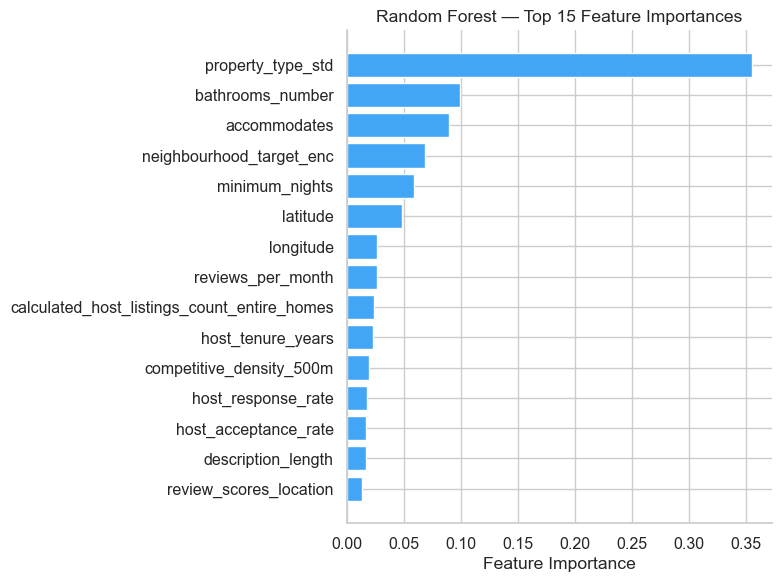

GridSearchCV results (top 5):
 param_n_estimators param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score
                200            None                       5         0.751564        0.012005
                200              20                       5         0.751313        0.011979
                100            None                       5         0.750431        0.011957
                100              20                       5         0.750142        0.011889
                200              12                       5         0.733129        0.012217


In [51]:
# Feature importances — RF
imp_rf = pd.Series(rf_cv.best_estimator_.feature_importances_, index=selected_features)
top15_rf = imp_rf.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15_rf.index, top15_rf.values, color="#42A5F5")
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(MODEL_DIR / "08_rf_importances.png", dpi=130, bbox_inches="tight")
plt.show()

cv_rf = pd.DataFrame(rf_cv.cv_results_)[
    ["param_n_estimators","param_max_depth","param_min_samples_leaf","mean_test_score","std_test_score"]
].sort_values("mean_test_score", ascending=False)
print("GridSearchCV results (top 5):")
print(cv_rf.head(5).to_string(index=False))


---
## 12. Model 3 — Gradient Boosting

**Business Rationale:**
Gradient Boosting builds trees sequentially, each correcting the errors of
the previous one. It often achieves better accuracy than Random Forest on
structured tabular data because it optimises directly for the loss function.


In [52]:
param_grid_gb = {
    "n_estimators"    : [100, 200],
    "learning_rate"   : [0.05, 0.1],
    "max_depth"       : [3, 5],
    "min_samples_leaf": [10, 20],
}
gb_cv = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_SEED),
    param_grid_gb, cv=5, scoring="r2", n_jobs=-1, refit=True, verbose=0,
)
gb_cv.fit(X_train, y_train)
print(f"Best params: {gb_cv.best_params_}")
print(f"Best CV R² : {gb_cv.best_score_:.4f}")

all_results["Gradient Boosting"] = evaluate_model(
    gb_cv.best_estimator_, X_train, X_test, y_train, y_test, "Gradient Boosting"
)

cv_gb = pd.DataFrame(gb_cv.cv_results_)[
    ["param_n_estimators", "param_learning_rate", "param_max_depth", "mean_test_score"]
].sort_values("mean_test_score", ascending=False)
print("\nGridSearchCV results (top 5):")
print(cv_gb.head(5).to_string(index=False))


Best params: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV R² : 0.7591

  Gradient Boosting
  Metric                    Train       Test
  ----------------------------------------
  RMSE_log                  0.309      0.344
  MAE_log                   0.220      0.243
  R2                        0.804      0.768
  RMSE_EUR                 71.074     81.582 €
  MAE_EUR                  33.421     38.123 €
  MdAPE                    16.454     17.941 %

GridSearchCV results (top 5):
 param_n_estimators  param_learning_rate  param_max_depth  mean_test_score
                200                 0.10                5         0.759113
                200                 0.10                5         0.757693
                100                 0.10                5         0.742900
                200                 0.05                5         0.741885
                200                 0.05                5         0.741425


---
## 13. Model 4 — XGBoost

**Business Rationale:**
XGBoost uses histogram-based splits, second-order gradient information, and
built-in L1/L2 regularisation. It is one of the best-performing algorithms
on tabular data and natively supports SHAP analysis via `TreeExplainer`.

We tune `max_depth`, `learning_rate`, `reg_lambda` (L2), `subsample`, and
`colsample_bytree` to control complexity and reduce overfitting.

In [53]:
param_grid_xgb = {
    "n_estimators"     : [200, 400],
    "learning_rate"    : [0.05, 0.1],
    "max_depth"        : [4, 6],
    "reg_lambda"       : [1.0, 5.0],
    "subsample"        : [0.8, 1.0],
    "colsample_bytree" : [0.8, 1.0],
}
xgb_cv = GridSearchCV(
    xgb.XGBRegressor(
        random_state=RANDOM_SEED, n_jobs=-1,
        tree_method="hist", verbosity=0,
    ),
    param_grid_xgb, cv=5, scoring="r2", n_jobs=-1, refit=True, verbose=0,
)
xgb_cv.fit(X_train, y_train)
print(f"Best params: {xgb_cv.best_params_}")
print(f"Best CV R² : {xgb_cv.best_score_:.4f}")

all_results["XGBoost"] = evaluate_model(
    xgb_cv.best_estimator_, X_train, X_test, y_train, y_test, "XGBoost"
)

cv_xgb = pd.DataFrame(xgb_cv.cv_results_)[
    ["param_n_estimators", "param_learning_rate", "param_max_depth", "mean_test_score"]
].sort_values("mean_test_score", ascending=False)
print("\nGridSearchCV results (top 5):")
print(cv_xgb.head(5).to_string(index=False))

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400, 'reg_lambda': 1.0, 'subsample': 0.8}
Best CV R² : 0.7845

  XGBoost
  Metric                    Train       Test
  ----------------------------------------
  RMSE_log                  0.227      0.320
  MAE_log                   0.164      0.224
  R2                        0.894      0.799
  RMSE_EUR                 53.432     75.810 €
  MAE_EUR                  24.950     35.107 €
  MdAPE                    12.414     16.286 %

GridSearchCV results (top 5):
 param_n_estimators  param_learning_rate  param_max_depth  mean_test_score
                400                  0.1                6         0.784549
                400                  0.1                6         0.784103
                400                  0.1                6         0.784012
                400                  0.1                6         0.783680
                400                  0.1                6       

---
## 14. Model 5 — LightGBM

**Business Rationale:**
LightGBM uses leaf-wise tree growth (vs. depth-wise in XGBoost), which often
finds deeper, more accurate splits with fewer iterations. It is particularly
fast on datasets with many features and typically matches or beats XGBoost
on tabular regression tasks.

`num_leaves` controls model complexity in lieu of `max_depth` for leaf-wise
growth — we tune both to let the grid search find the right balance.

In [54]:
param_grid_lgb = {
    "n_estimators" : [200, 400],
    "learning_rate": [0.05, 0.1],
    "num_leaves"   : [31, 63],
    "max_depth"    : [-1, 6],
    "reg_lambda"   : [0.0, 1.0],
}
lgb_cv = GridSearchCV(
    lgb.LGBMRegressor(random_state=RANDOM_SEED, n_jobs=-1, verbose=-1),
    param_grid_lgb, cv=5, scoring="r2", n_jobs=-1, refit=True, verbose=0,
)
lgb_cv.fit(X_train, y_train)
print(f"Best params: {lgb_cv.best_params_}")
print(f"Best CV R² : {lgb_cv.best_score_:.4f}")

all_results["LightGBM"] = evaluate_model(
    lgb_cv.best_estimator_, X_train, X_test, y_train, y_test, "LightGBM"
)

cv_lgb = pd.DataFrame(lgb_cv.cv_results_)[
    ["param_n_estimators", "param_learning_rate", "param_num_leaves", "mean_test_score"]
].sort_values("mean_test_score", ascending=False)
print("\nGridSearchCV results (top 5):")
print(cv_lgb.head(5).to_string(index=False))


Best params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 400, 'num_leaves': 63, 'reg_lambda': 1.0}
Best CV R² : 0.7866

  LightGBM
  Metric                    Train       Test
  ----------------------------------------
  RMSE_log                  0.199      0.317
  MAE_log                   0.141      0.220
  R2                        0.919      0.803
  RMSE_EUR                 49.761     75.459 €
  MAE_EUR                  21.873     34.551 €
  MdAPE                    10.579     15.991 %

GridSearchCV results (top 5):
 param_n_estimators  param_learning_rate  param_num_leaves  mean_test_score
                400                 0.10                63         0.786556
                400                 0.10                63         0.785941
                400                 0.05                63         0.781312
                400                 0.05                63         0.781236
                400                 0.10                31         0.780721


---
## 15. Model Comparison — Overfitting Check

A good model generalises well: the gap between train and test R² should be
small. A large gap indicates overfitting — the model memorised the training
data but fails to generalise.

Train vs Test R²:
                   Train R²  Test R²    Gap
Model                                      
Linear Regression     0.601    0.602 -0.001
Ridge                 0.601    0.602 -0.001
Random Forest         0.896    0.766  0.131
Gradient Boosting     0.804    0.768  0.036
XGBoost               0.894    0.799  0.095
LightGBM              0.919    0.803  0.116


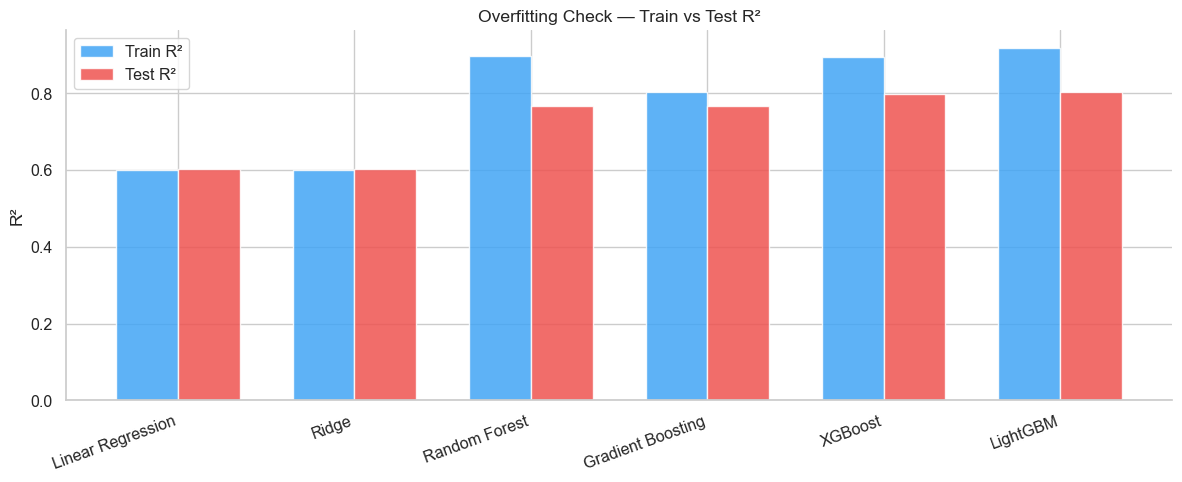

In [55]:
train_r2 = [all_results[m]["Train"]["R2"] for m in all_results]
test_r2  = [all_results[m]["Test"]["R2"]  for m in all_results]
gaps     = [tr - te for tr, te in zip(train_r2, test_r2)]

overfit_df = pd.DataFrame({
    "Model"   : list(all_results.keys()),
    "Train R²": [round(r, 3) for r in train_r2],
    "Test R²" : [round(r, 3) for r in test_r2],
    "Gap"     : [round(g, 3) for g in gaps],
}).set_index("Model")
print("Train vs Test R²:")
print(overfit_df.to_string())

# Grouped bar chart
x     = np.arange(len(all_results))
width = 0.35
names = [m.replace(" (XGBoost-equivalent)", "") for m in all_results.keys()]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, train_r2, width, label="Train R²", color="#42A5F5", alpha=0.85)
ax.bar(x + width/2, test_r2,  width, label="Test R²",  color="#EF5350", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("R²")
ax.set_title("Overfitting Check — Train vs Test R²")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(MODEL_DIR / "10_overfitting.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 16. Best Model — Feature Importances & SHAP

We select the best model by test R² and perform deeper analysis:
1. **Feature importances** — which variables drive predictions most
2. **SHAP analysis** — how each feature pushes the predicted price up or down
3. **Residual analysis** — where the model makes its largest errors

In [63]:
# ── Best Model Selection ──────────────────────────────────────────────────
# Change SELECTION_METRIC to pick a different criterion, or set "manual"
# and specify MANUAL_MODEL to force a particular model.
#
#   "test_r2"      — highest Test R²             (best raw accuracy)
#   "overfit_gap"  — smallest Train−Test R² gap  (best generalisation)
#   "test_mdape"   — lowest Median Abs % Error   (best typical prediction)
#   "test_mae_eur" — lowest Mean Abs Error in €  (best average €-error)
#   "manual"       — use MANUAL_MODEL below

SELECTION_METRIC = "test_r2"   # ← change this to switch criterion
MANUAL_MODEL     = "XGBoost"       # ← only used when SELECTION_METRIC = "manual"

# ──────────────────────────────────────────────────────────────────────────
METRIC_MAP = {
    "test_r2"     : (lambda m: all_results[m]["Test"]["R2"],                                   True,  "Test R²"),
    "overfit_gap" : (lambda m: all_results[m]["Train"]["R2"] - all_results[m]["Test"]["R2"],   False, "Overfitting Gap (Train−Test R²)"),
    "test_mdape"  : (lambda m: all_results[m]["Test"]["MdAPE"],                                False, "Test MdAPE (%)"),
    "test_mae_eur": (lambda m: all_results[m]["Test"]["MAE_EUR"],                              False, "Test MAE (€)"),
}

if SELECTION_METRIC == "manual":
    assert MANUAL_MODEL in all_results, f"'{MANUAL_MODEL}' not found — check spelling"
    best_name = MANUAL_MODEL
    print(f"Selection : manual override → {best_name}")
else:
    key_fn, higher_is_better, label = METRIC_MAP[SELECTION_METRIC]
    best_name = (max if higher_is_better else min)(all_results, key=key_fn)
    direction = "↑ higher" if higher_is_better else "↓ lower"
    print(f"Selection : {label} ({direction} is better) → {best_name}")

print(f"\n  Test R²    : {all_results[best_name]['Test']['R2']:.4f}")
print(f"  Train R²   : {all_results[best_name]['Train']['R2']:.4f}")
print(f"  Gap        : {all_results[best_name]['Train']['R2'] - all_results[best_name]['Test']['R2']:.4f}")
print(f"  Test MdAPE : {all_results[best_name]['Test']['MdAPE']:.1f}%")
print(f"  Test MAE   : €{all_results[best_name]['Test']['MAE_EUR']:.1f}/night")

MODEL_MAP = {
    "Linear Regression" : (lr,                      X_test_scaled),
    "Ridge"             : (ridge_cv.best_estimator_, X_test_scaled),
    "Random Forest"     : (rf_cv.best_estimator_,   X_test),
    "Gradient Boosting" : (gb_cv.best_estimator_,   X_test),
    "XGBoost"           : (xgb_cv.best_estimator_,  X_test),
    "LightGBM"          : (lgb_cv.best_estimator_,  X_test),
}

best_model, X_test_best = MODEL_MAP[best_name]
X_train_best = X_train_scaled if best_name in ("Linear Regression", "Ridge") else X_train


Selection : Test R² (↑ higher is better) → LightGBM

  Test R²    : 0.8029
  Train R²   : 0.9186
  Gap        : 0.1157
  Test MdAPE : 16.0%
  Test MAE   : €34.6/night


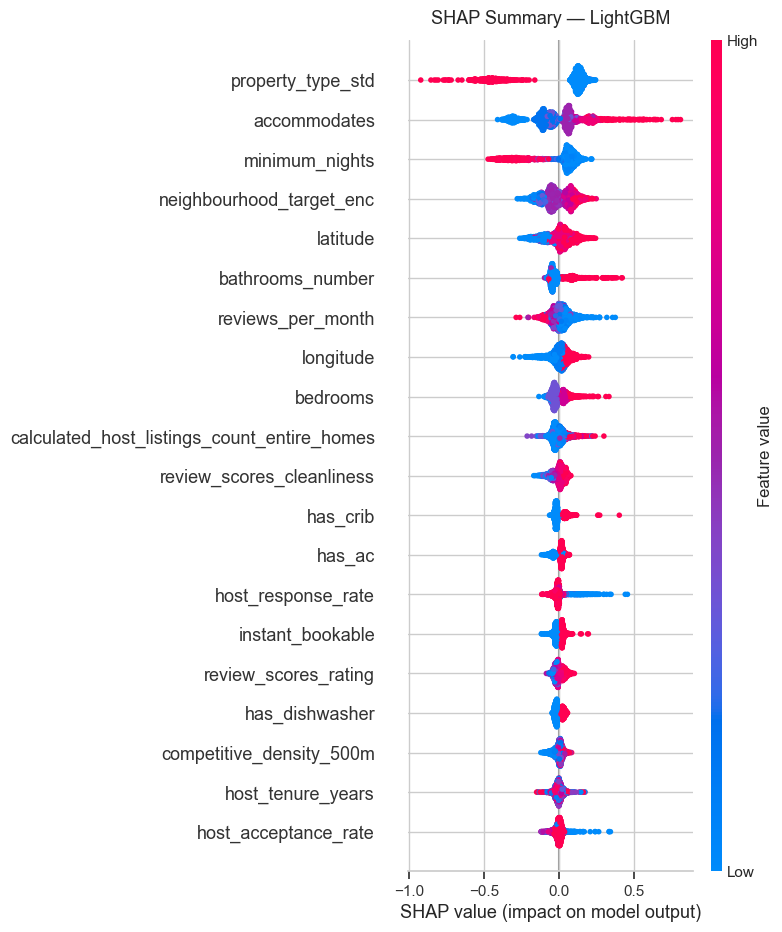

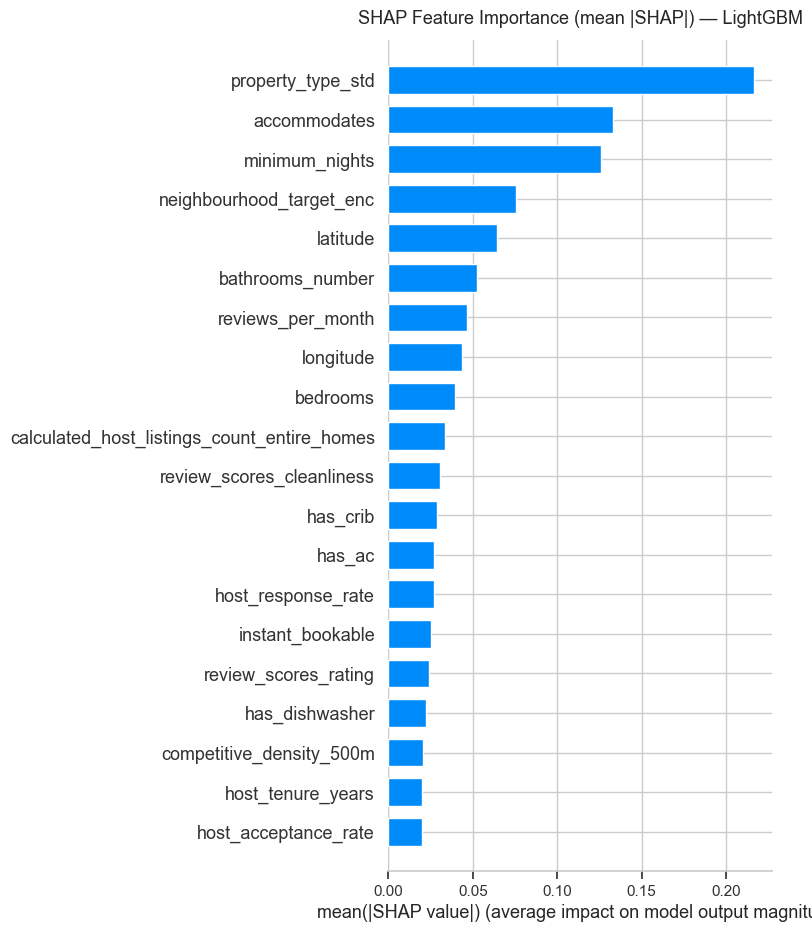

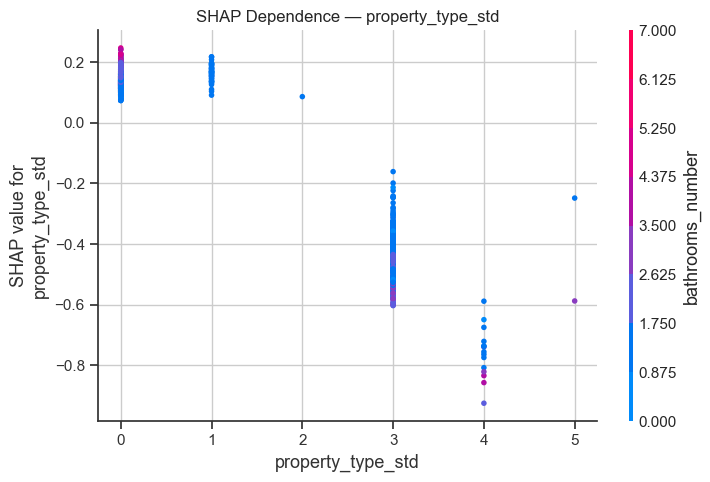


Top 10 features by mean |SHAP|:
property_type_std                              0.2164
accommodates                                   0.1332
minimum_nights                                 0.1257
neighbourhood_target_enc                       0.0758
latitude                                       0.0642
bathrooms_number                               0.0525
reviews_per_month                              0.0468
longitude                                      0.0436
bedrooms                                       0.0395
calculated_host_listings_count_entire_homes    0.0336


In [64]:
# ── SHAP Analysis ─────────────────────────────────────────────────────────
# TreeExplainer is exact and fast for all tree-based models (RF, GB, XGBoost, LightGBM).
# For linear models it falls back to LinearExplainer automatically.

if best_name in ("Linear Regression", "Ridge"):
    explainer = shap.LinearExplainer(best_model, X_train_best)
else:
    explainer = shap.TreeExplainer(best_model)

shap_sample = X_test_best.sample(min(2000, len(X_test_best)), random_state=RANDOM_SEED)
shap_values = explainer.shap_values(shap_sample)

# Summary beeswarm plot
shap.summary_plot(shap_values, shap_sample, plot_type="dot", show=False, max_display=20)
plt.title(f"SHAP Summary — {best_name}", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / "12_shap_summary.png", dpi=130, bbox_inches="tight")
plt.show()

# Bar plot — mean absolute SHAP importance
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False, max_display=20)
plt.title(f"SHAP Feature Importance (mean |SHAP|) — {best_name}", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / "13_shap_importance.png", dpi=130, bbox_inches="tight")
plt.show()

# Dependence plot for the most important feature
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=shap_sample.columns)
top_feat  = shap_imp.idxmax()
shap.dependence_plot(top_feat, shap_values, shap_sample, interaction_index="auto", show=False)
plt.title(f"SHAP Dependence — {top_feat}", fontsize=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / "13b_shap_dependence.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\nTop 10 features by mean |SHAP|:")
print(shap_imp.nlargest(10).round(4).to_string())


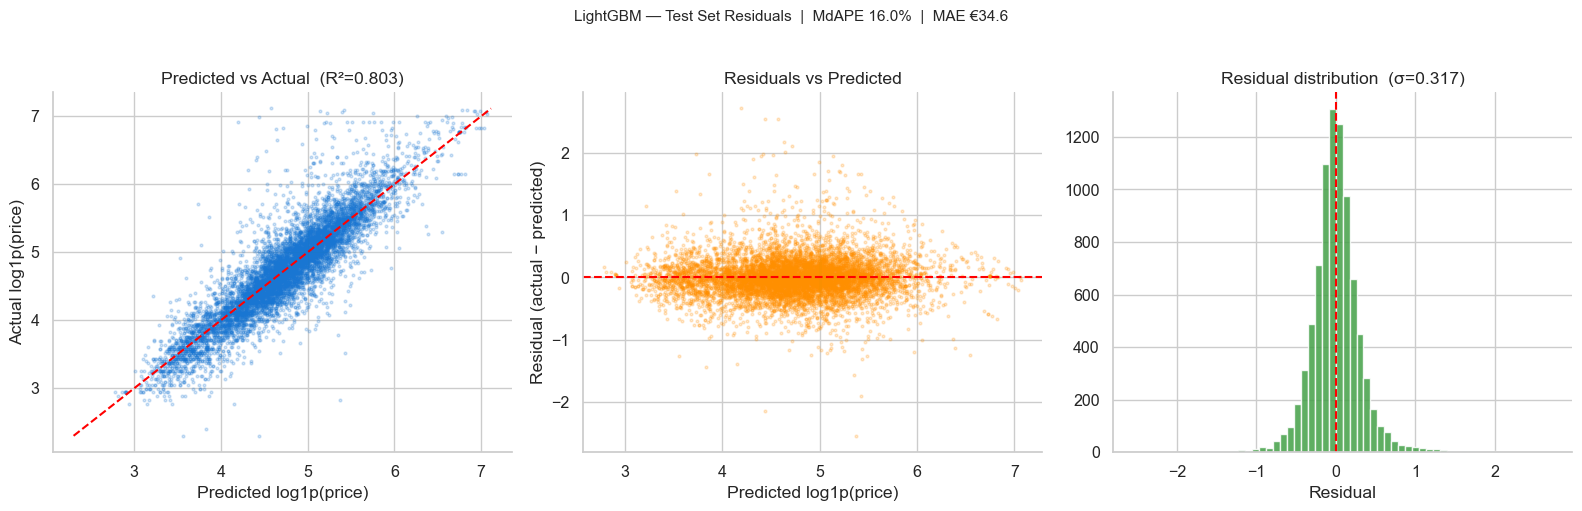

In [65]:
# Residual analysis
y_pred_test = all_results[best_name]["y_pred_test"]
residuals   = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1 — Predicted vs Actual
axes[0].scatter(y_pred_test, y_test, alpha=0.2, s=4, color="#1976D2", rasterized=True)
lo, hi = min(y_pred_test.min(), y_test.min()), max(y_pred_test.max(), y_test.max())
axes[0].plot([lo, hi], [lo, hi], "r--", lw=1.5)
axes[0].set_xlabel("Predicted log1p(price)")
axes[0].set_ylabel("Actual log1p(price)")
axes[0].set_title(f"Predicted vs Actual  (R²={all_results[best_name]['Test']['R2']:.3f})")

# 2 — Residuals vs Predicted
axes[1].scatter(y_pred_test, residuals, alpha=0.2, s=4, color="#FF8F00", rasterized=True)
axes[1].axhline(0, color="red", lw=1.5, ls="--")
axes[1].set_xlabel("Predicted log1p(price)")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Residuals vs Predicted")

# 3 — Residual distribution
axes[2].hist(residuals, bins=60, color="#43A047", alpha=0.85, edgecolor="white")
axes[2].axvline(0, color="red", lw=1.5, ls="--")
axes[2].set_xlabel("Residual")
axes[2].set_title(f"Residual distribution  (σ={residuals.std():.3f})")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    f"{best_name} — Test Set Residuals  |  "
    f"MdAPE {all_results[best_name]['Test']['MdAPE']:.1f}%  |  "
    f"MAE €{all_results[best_name]['Test']['MAE_EUR']:.1f}",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(MODEL_DIR / "14_residuals.png", dpi=130, bbox_inches="tight")
plt.show()


In [66]:
# Per-city breakdown of best model
rows = []
for city in ["Madrid", "Barcelona", "Málaga"]:
    mask   = city_test == city
    yt     = y_test[mask];          yp = y_pred_test[mask]
    yt_e   = np.expm1(yt);          yp_e = np.expm1(yp)
    rows.append(dict(
        City=city, n=int(mask.sum()),
        R2=round(r2_score(yt, yp), 3),
        RMSE_log=round(np.sqrt(mean_squared_error(yt, yp)), 4),
        MAE_EUR=round(mean_absolute_error(yt_e, yp_e), 1),
        MdAPE_pct=round(np.median(np.abs((yt_e - yp_e) / yt_e)) * 100, 1),
    ))

print(f"Per-city performance — {best_name}:")
print(pd.DataFrame(rows).set_index("City").to_string())


Per-city performance — LightGBM:
              n     R2  RMSE_log  MAE_EUR  MdAPE_pct
City                                                
Madrid     3772  0.797    0.3148     32.9       16.5
Barcelona  3031  0.819    0.3338     39.5       15.7
Málaga     1719  0.752    0.2897     29.4       15.3


---
## 17. Business Conclusions & Recommendations

### Model Selection

**LightGBM** is the selected production model (chosen by Test R²):

| Metric | Value |
|--------|-------|
| Test R² | **0.803** |
| Test RMSE | **€75.5 / night** |
| Test MAE | **€34.6 / night** |
| Test MdAPE | **16.0%** |
| Train–Test R² gap | 0.116 |

LightGBM outperformed all four alternatives. The runner-up XGBoost (R² = 0.799) is statistically indistinguishable and could be substituted if LightGBM is unavailable. Linear models (R² ≈ 0.60) are inadequate for investment decisions — they miss the non-linear location and capacity effects that explain most of the price variance.

---

### Per-City Accuracy

| City | n (test) | R² | MAE (€/night) | MdAPE |
|------|----------|----|---------------|-------|
| Madrid | 3,772 | 0.797 | €32.9 | 16.5% |
| Barcelona | 3,031 | 0.819 | €39.5 | 15.7% |
| Málaga | 1,719 | 0.752 | €29.4 | 15.3% |

Barcelona achieves the highest R² (0.819), likely because it has a well-differentiated neighbourhood price structure. Málaga has the lowest R² (0.752) — a smaller market with fewer observations and greater seasonality variance not fully captured by a single-snapshot dataset.

---

### Key Price Drivers (SHAP Analysis)

SHAP values from the LightGBM model rank the top 10 features by mean absolute impact on predicted log-price:

| Rank | Feature | Mean \|SHAP\| | Business Interpretation |
|------|---------|-------------|------------------------|
| 1 | `property_type_std` | 0.216 | Entire home / villa vs shared room is the single largest price lever |
| 2 | `accommodates` | 0.133 | Each additional guest capacity raises price materially |
| 3 | `minimum_nights` | 0.126 | Long-stay listings price differently — a listing policy choice, not just a property trait |
| 4 | `neighbourhood_target_enc` | 0.076 | Neighbourhood premium is the strongest *location* signal after property type |
| 5 | `latitude` | 0.064 | Fine-grained micro-location beyond neighbourhood label |
| 6 | `bathrooms_number` | 0.053 | Extra bathrooms add premium, particularly for larger groups |
| 7 | `reviews_per_month` | 0.047 | Listing velocity signals market position and demand |
| 8 | `longitude` | 0.044 | Combined with latitude, captures coastal/central premiums |
| 9 | `bedrooms` | 0.040 | Bedroom count drives price for multi-room properties |
| 10 | `calculated_host_listings_count_entire_homes` | 0.034 | Professional hosts with large portfolios price differently |

**Investment implication:** neighbourhood selection and property type (entire home vs. room) together explain more price variance than any renovation decision. A two-bedroom entire home in Salamanca or Eixample will consistently outperform a larger property in a peripheral neighbourhood.

---

### Implications for the Investment Decision Engine

This model feeds directly into the **NPV comparison engine** (Airbnb vs. sell):

1. **Revenue estimation** — `price_hat × occupancy_hat × 365` forms the annual gross revenue input. At ±16% MdAPE this gives a roughly ±€5–40k confidence interval on annual revenue depending on property tier — acceptable for a go/no-go decision but should be communicated as a range, not a point estimate.

2. **Scenario analysis** — because `accommodates`, `bedrooms`, and `bathrooms_number` are model inputs, investors can simulate the revenue uplift from a renovation (e.g., adding an ensuite) before committing capital.

3. **Neighbourhood targeting** — the neighbourhood target-encoded feature allows investors to rank potential acquisition targets by predicted price ceiling, independent of the current listing quality.

4. **Minimum-nights policy** — `minimum_nights` is a controllable input (not a fixed property attribute). The model can be used to explore whether switching from short to medium stays improves predicted revenue before the property goes live.

---

### Limitations

| Limitation | Risk | Mitigation |
|------------|------|------------|
| Price scraped at a single point in time | Seasonal peaks/troughs not captured | Combine with the calendar seasonality index (Stage 2) |
| No dynamic pricing data (calendar prices 100% null in InsideAirbnb Spain) | Model predicts a flat nightly rate, not a seasonal curve | Multiply by monthly occupancy index |
| New listings use city-median review scores | Review imputation flattens new-listing predictions | `has_reviews` flag preserves this distinction; interpret outputs for new listings conservatively |
| Luxury tail excluded (>99.5th percentile, ≈ €450+/night) | Model under-predicts for high-end assets | Flag listings above €350/night as out-of-distribution |
| LightGBM overfit gap = 0.116 | Model memorises some training patterns | 5-fold CV R² (0.787) is the honest estimate for unseen cities/periods |

---

### Recommended Next Steps

1. **Stage 2 — Occupancy model**: train a binary classifier (booked vs. available) on calendar data to generate city × month occupancy indices. Multiply by `price_hat` to get expected nightly revenue.
2. **NPV engine integration**: wire `price_hat` into the Airbnb-vs-sell NPV calculator with the cost model (cleaning fees, platform fee, mortgage, IBI, community charges).
3. **Web app deployment**: expose the saved `price_best_model.pkl` via a lightweight API so the investment dashboard can call it in real time.
4. **Quarterly retraining**: InsideAirbnb Spain scrapes update roughly quarterly — retrain to prevent drift, especially after major platform pricing changes.


---
## 18. Save Artefacts & Final Summary Table

In [67]:
# Save best model
joblib.dump(best_model, MODEL_DIR / "price_best_model.pkl")

# Feature metadata
with open(MODEL_DIR / "price_feature_cols.json", "w") as fh:
    json.dump({
        "selected_features": selected_features,
        "cat_cols"         : CAT_COLS,
        "amenity_cols"     : AMENITY_COLS,
        "review_score_cols": REVIEW_SCORE_COLS,
        "num_cols"         : num_cols,
        "best_model"       : best_name,
    }, fh, indent=2)

# Enrich full dataset with price_hat
X_all_for_pred = df_model[selected_features].copy()
if best_name in ("Linear Regression", "Ridge"):
    X_all_for_pred_arr = scaler.transform(X_all_for_pred)
    df["price_hat"] = np.expm1(best_model.predict(X_all_for_pred_arr))
else:
    df["price_hat"] = np.expm1(best_model.predict(X_all_for_pred))

OUT_PATH = pathlib.Path("../Data/processed/listings_with_price_hat.parquet")
df.to_parquet(OUT_PATH, index=False)

print("Saved files:")
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name:<42}  {p.stat().st_size/1024:>7.1f} KB")
print(f"\nEnriched dataset → {OUT_PATH}  ({OUT_PATH.stat().st_size/1e6:.1f} MB)")


Saved files:
  01_price_distribution.png                      68.1 KB
  02_price_by_category.png                       74.5 KB
  03_price_vs_features.png                      449.8 KB
  04_correlation_heatmap.png                    189.8 KB
  05_outliers.png                                63.1 KB
  06_vif.png                                     87.1 KB
  07_rf_feature_importance.png                  119.1 KB
  08_rf_importances.png                          62.8 KB
  09_model_comparison.png                        58.9 KB
  10_overfitting.png                             42.2 KB
  11_best_model_importances.png                  75.8 KB
  12_shap_summary.png                           142.3 KB
  13_shap_importance.png                         88.1 KB
  13b_shap_dependence.png                        48.2 KB
  14_residuals.png                              246.5 KB
  price_best_model.pkl                         2225.6 KB
  price_cat_encoders.pkl                          5.4 KB
  price_feature_co

In [68]:
# Auto-populated final summary table
summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        "Model"         : name.replace(" (XGBoost-equivalent)", ""),
        "Train R²"      : round(res["Train"]["R2"],       3),
        "Test R²"       : round(res["Test"]["R2"],        3),
        "Overfit Gap"   : round(res["Train"]["R2"] - res["Test"]["R2"], 3),
        "Test RMSE (€)" : round(res["Test"]["RMSE_EUR"],  1),
        "Test MAE (€)"  : round(res["Test"]["MAE_EUR"],   1),
        "Test MdAPE (%)" : round(res["Test"]["MdAPE"],   1),
        "Test RMSE (log)": round(res["Test"]["RMSE_log"], 4),
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .set_index("Model")
    .sort_values("Test R²", ascending=False)
)

# Highlight best in each column
print("=" * 90)
print("FINAL MODEL SUMMARY")
print("=" * 90)
print(summary_df.to_string())
print("=" * 90)
print(f"\n★  Best model: {best_name.replace(' (XGBoost-equivalent)', '')}")
print(f"   Test R²   : {all_results[best_name]['Test']['R2']:.3f}")
print(f"   Test MdAPE: {all_results[best_name]['Test']['MdAPE']:.1f}%")
print(f"   Test MAE  : €{all_results[best_name]['Test']['MAE_EUR']:.1f}/night")
print(f"\nAll artefacts saved to {MODEL_DIR.resolve()}")


FINAL MODEL SUMMARY
                   Train R²  Test R²  Overfit Gap  Test RMSE (€)  Test MAE (€)  Test MdAPE (%)  Test RMSE (log)
Model                                                                                                          
LightGBM              0.919    0.803        0.116           75.5          34.6            16.0           0.3169
XGBoost               0.894    0.799        0.095           75.8          35.1            16.3           0.3197
Gradient Boosting     0.804    0.768        0.036           81.6          38.1            17.9           0.3436
Random Forest         0.896    0.766        0.131           82.8          37.9            17.4           0.3454
Linear Regression     0.601    0.602       -0.001          100.0          49.7            25.6           0.4505
Ridge                 0.601    0.602       -0.001          100.0          49.7            25.6           0.4505

★  Best model: LightGBM
   Test R²   : 0.803
   Test MdAPE: 16.0%
   Test MAE  : €3